
# Sensors and Signal Analysis 2026
Author: Nuno Azevedo Silva and Catarina Monteiro

### Hands-on activity 2

This notebook supports the second Hands-on activity where the students will determine the transfer function and calibrate a real-world sensor. 

For this we will utilize:

---

**Ultrasonic Distance Sensor**:

<img src="figs/principle.png" width="600"/>

An ultrasonic distance sensor works by emitting a high-frequency sound wave and measuring the time it takes for the echo to bounce back from an object. Using a microcontroller you send the sound pulse by sending a eletric pulse to the trigger, which then waits for an echo to determine the time delay $\Delta t$. The distance can be easily calculated as 

 $\delta =\frac{\Delta t}{2}  \times c_s$ 
 
where $c_s \approx 343 m/s $ is the speed of sound.


The sensor will be connected to an Arduino that has been pre-programmed accordingly (code given in microcontroller folder).

***Experimental Setup***

Connect the circuit as shown below:

<img src="figs/setup.png" width="600"/>

## Auxiliary functions to read data

In [237]:
import serial
import time
import numpy as np
import matplotlib.pyplot as plt

def open_serial(port, baud):
    ser = serial.Serial(port, baud, timeout=1)
    time.sleep(2)
    return ser

def read_data(ser, num_readings):

    readings = []

    for i in range(num_readings):
        line = ser.readline().decode(errors="ignore").strip()
        if line:
            readings.append(float(line))
        time.sleep(0.1)

    return np.array(readings)

def close_serial(ser):
    ser.close()

def remove_outliers(data, nreads_final=None, k=1):
    data = np.asarray(data, dtype=float)

    if data.size == 0:
        raise ValueError("Empty data")

    q1 = np.percentile(data, 25)
    q3 = np.percentile(data, 75)
    iqr = q3 - q1

    if iqr == 0:
        cleaned = data
    else:
        low = q1 - k * iqr
        high = q3 + k * iqr
        cleaned = data[(data >= low) & (data <= high)]

    cleaned = cleaned.tolist()

    if nreads_final is None:
        return cleaned

    if len(cleaned) < nreads_final:
        print("Not enough data points after outlier removal")
        return cleaned

    return cleaned[:nreads_final]


def save_data(data, stimulus, data_file="data.txt", stimulus_file="stimulus.txt"):
    data = np.asarray(data)

    with open(stimulus_file, "a") as f:
        f.write(f"{stimulus}\n")

    with open(data_file, "a") as f:
        line = " ".join(map(str, data))
        f.write(line + "\n")
    
    


<!-- ## 1. Acquire data -->

# 1. Acquire data

### Acquire data for several measurements of the same stimulus

In [531]:
data=np.array([])

n measures:  5


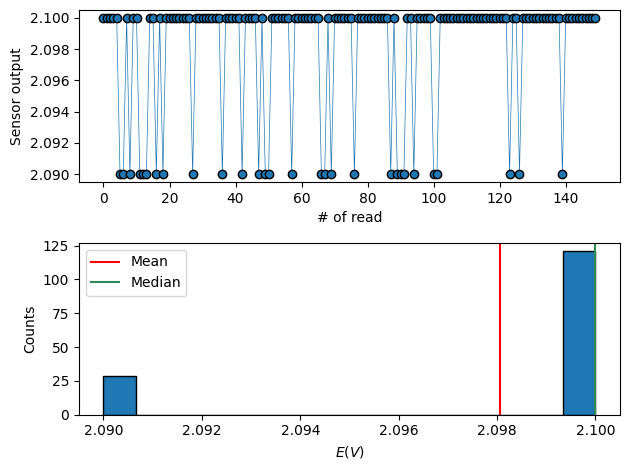

In [536]:
#Open Serial Port

port = "COM6" #Change this to match your port
baudrate = 9600

ser = open_serial(port, baudrate)


#Read data
n_points = 30
temp_data = read_data(ser, n_points)
data=np.concatenate([data,temp_data])
ser.close()

#Plot data
fig,ax = plt.subplots(2,1)
ax[0].plot(data, lw=0.5, marker='o',markeredgecolor='k')
ax[0].set_xlabel("# of read")
ax[0].set_ylabel('Sensor output')

print('n measures: ', int(len(data)/n_points))

ax[1].set_title(data)
ax[1].hist(data,bins=15,ec='k', )
ax[1].axvline(np.mean(data),label='Mean',color='r')
ax[1].axvline(np.median(data),label='Median',color='seagreen')
ax[1].set_title('')
ax[1].set_xlabel(r'$E(V)$')
ax[1].set_ylabel(r'Counts')
ax[1].legend()
fig.tight_layout()

In [537]:
#Save file
save_data(data, 1.5, data_file="data_sensor.txt", stimulus_file="stimulus.txt")

### Analyze the data to find the best estimator

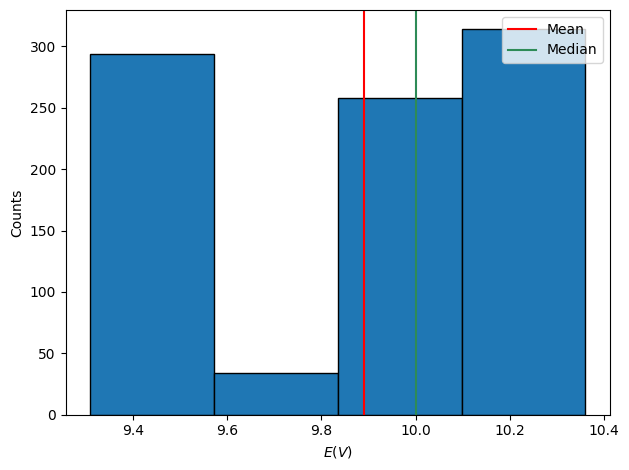

In [447]:
data_from_file = np.loadtxt("data_same_stimulus.txt")

fig,ax = plt.subplots()
ax.hist(data_from_file,bins=4,ec='k', )
ax.axvline(np.mean(data_from_file),label='Mean',color='r')
ax.axvline(np.median(data_from_file),label='Median',color='seagreen')
ax.set_title('')
ax.set_xlabel(r'$E(V)$')
ax.set_ylabel(r'Counts')
ax.legend()
fig.tight_layout()

What is the best estimator?

Sometimes in the real world noise does not follow a perfect behaviour.The important thing is to make a decision. What is the best decision for this situation?

# 2. Data Analysis

Using what you have previously explored in the Jupyter notebook activity try to calibrate your sensor.
- Compute the transfer function and characterize your sensor

In [ ]:
from scipy.interpolate import CubicSpline

#Load all data
stimulus = np.loadtxt("stimulus.txt")
sensor_data = np.loadtxt('data_sensor.txt')

output_sensor = []
uncertainty_sensor = []

for stim in sensor_data:
    output_sensor.append(np.mean(stim))
    uncertainty_sensor.append(2*np.std(stim))


#Choose the maximum uncertainty for all measures
uncertainty_sensor_max = np.ones_like(uncertainty_sensor) * np.max(uncertainty_sensor)

Text(0.5, 1.0, 'Sensitivity')

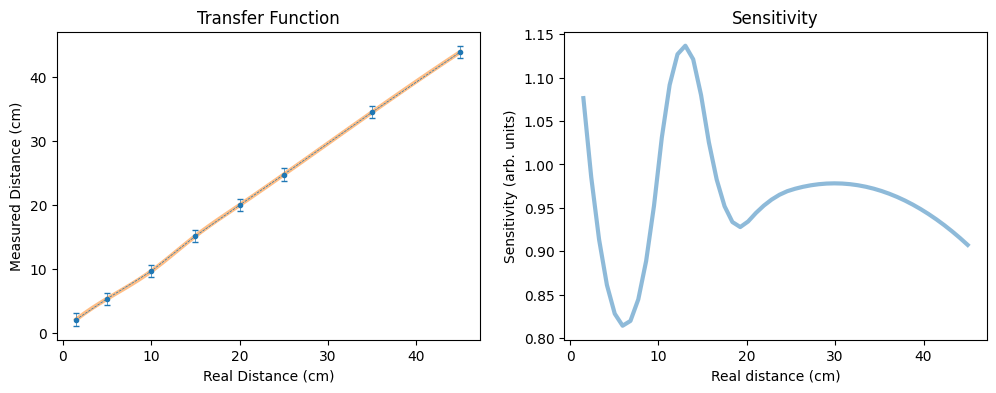

In [547]:
fig, ax = plt.subplots(1, 2, figsize = (12,4))
stimulus_extended = np.linspace(np.min(stimulus),np.max(stimulus),50)
transfer_function = CubicSpline(stimulus, output_sensor)


ax[0].errorbar(stimulus, output_sensor, yerr = uncertainty_sensor_max, capsize=2,ls='--',lw=0.5,ms=3,marker='o')
ax[0].plot(stimulus_extended, transfer_function(stimulus_extended), ls='-',lw=3,alpha=0.5)
ax[0].set_xlabel('Real Distance (cm)')
ax[0].set_ylabel('Measured Distance (cm)')
ax[0].set_title('Transfer Function')

ax[1].plot(stimulus_extended, transfer_function(stimulus_extended, nu=1), ls='-',lw=3,alpha=0.5)
ax[1].set_xlabel('Real distance (cm)')
ax[1].set_ylabel('Sensitivity (arb. units)')
ax[1].set_title('Sensitivity')